# Lab 1 - Data analysis and visualization
Loads the latest raw log, computes descriptive statistics, and produces the plots.
Run from the `python/` folder.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
RAW_DIR, PROC_DIR, FIG_DIR = ROOT / "data/raw", ROOT / "data/processed", ROOT / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = sorted(RAW_DIR.glob("sensor_log_*.csv"))[-1]   # newest log; set manually if needed
print("Using", RAW_FILE.name)

Using sensor_log_20260929_171534.csv


In [2]:
df = pd.read_csv(RAW_FILE, na_values=["NaN", "nan"])
df["t_s"] = df["timestamp"] - df["timestamp"].iloc[0]
# Wall-clock time (HH:MM:SS) recorded by acquisition.ipynb; fall back to seconds for older logs
if "pc_time" in df:
    df["clock"] = pd.to_datetime(df["pc_time"], format="%H:%M:%S", errors="coerce")
else:
    df["clock"] = pd.NaT
USE_CLOCK = bool(df["clock"].notna().all())
df["x"] = df["clock"] if USE_CLOCK else df["t_s"]
XLABEL = "Time (HH:MM:SS)" if USE_CLOCK else "Time (s)"
fresh = df[(df.dht_fresh == 1) & (df.valid == 1)]      # genuine DHT11 samples
print(df.head())

   timestamp  temp  humidity  light  motion  temp_cal  temp_filt  delta_temp  \
0     604.02  30.5      54.4    1.0       0     32.61      32.61         0.0   
1     605.02  30.5      54.4    1.0       0     32.61      32.61         NaN   
2     606.02  30.5      54.4    1.0       0     32.61      32.61         0.0   
3     607.02  30.5      54.4    1.0       0     32.61      32.61         NaN   
4     608.02  30.5      54.4    1.0       0     32.61      32.61         0.0   

   status  valid  dht_fresh  event  ref_temp   pc_time  t_s  \
0  NORMAL      1          1      0     32.43  17:15:37  0.0   
1  NORMAL      1          0      0     32.42  17:15:38  1.0   
2  NORMAL      1          1      0     32.35  17:15:39  2.0   
3  NORMAL      1          0      0     32.44  17:15:40  3.0   
4  NORMAL      1          1      0     32.41  17:15:41  4.0   

                clock                   x  
0 1900-01-01 17:15:37 1900-01-01 17:15:37  
1 1900-01-01 17:15:38 1900-01-01 17:15:38  
2 1900-0

## Descriptive statistics

In [3]:
n_obs = len(df)
duration = df["timestamp"].max() - df["timestamp"].min()
invalid_dht_reads = int(((df.dht_fresh == 1) & (df.valid == 0)).sum())   # failed DHT11 reads
invalid_rows = int((df.valid == 0).sum())                                # rows flagged INVALID (incl. held rows)
n_events = int(df["event"].sum())

print(f"Observations (rows)     : {n_obs}")
print(f"Duration                : {duration:.1f} s ({duration/60:.1f} min)")
print(f"Invalid DHT11 reads     : {invalid_dht_reads}  ({100*invalid_dht_reads/max(1,(df.dht_fresh==1).sum()):.1f} % of reads)")
print(f"Rows flagged INVALID    : {invalid_rows}")
print(f"Detected events         : {n_events}")

stats_tbl = pd.concat({
    "temp_raw (C)": fresh["temp"], "temp_cal (C)": fresh["temp_cal"], "temp_filt (C)": fresh["temp_filt"],
    "humidity (%)": fresh["humidity"], "light (0-1)": df["light"], "motion (0/1)": df["motion"],
}, axis=1).agg(["count", "mean", "min", "max", "std"]).T
stats_tbl

Observations (rows)     : 600
Duration                : 599.0 s (10.0 min)
Invalid DHT11 reads     : 0  (0.0 % of reads)
Rows flagged INVALID    : 0
Detected events         : 19


,count,mean,min,max,std
temp_raw (C),300.0,30.388000,30.30,30.50,0.057157
temp_cal (C),300.0,32.477900,32.38,32.61,0.065075
temp_filt (C),300.0,32.479500,32.38,32.61,0.063262
humidity (%),300.0,54.150333,53.50,54.60,0.431262
light (0-1),600.0,1.000000,1.00,1.00,0.000000
motion (0/1),600.0,0.043333,0.00,1.00,0.203776


In [4]:
print(df["status"].value_counts())

status
NORMAL    574
MOTION     26
Name: count, dtype: int64


## Effective sampling rate and filter effect

In [5]:
rates = pd.Series({
    "LDR / PIR (main loop)": n_obs / duration,
    "DHT11 (fresh valid samples)": len(fresh) / duration,
}, name="effective rate (Hz)")
print(rates.round(3))

d_raw, d_filt = fresh["temp_cal"].diff().std(), fresh["temp_filt"].diff().std()
print(f"\nStd of sample-to-sample change: unfiltered {d_raw:.3f} C, filtered {d_filt:.3f} C "
      f"-> noise reduced by {100*(1-d_filt/d_raw):.1f} %")
print(f"Std of the signal itself       : unfiltered {fresh.temp_cal.std():.3f} C, filtered {fresh.temp_filt.std():.3f} C")

# Optional cross-check with the fitted calibration model
model_path = PROC_DIR / "calibration_model.json"
if model_path.exists():
    m = json.loads(model_path.read_text())
    py_cal = m["gain"] * fresh["temp"] + m["offset"]
    print(f"\nModel gain={m['gain']:.5f} offset={m['offset']:.5f}; "
          f"max |firmware - python| = {(py_cal - fresh['temp_cal']).abs().max():.3f} C")

LDR / PIR (main loop)          1.002
DHT11 (fresh valid samples)    0.501
Name: effective rate (Hz), dtype: float64

Std of sample-to-sample change: unfiltered 0.026 C, filtered 0.008 C -> noise reduced by 69.5 %
Std of the signal itself       : unfiltered 0.065 C, filtered 0.063 C

Model gain=1.11587 offset=-1.42758; max |firmware - python| = 0.005 C


## Plots

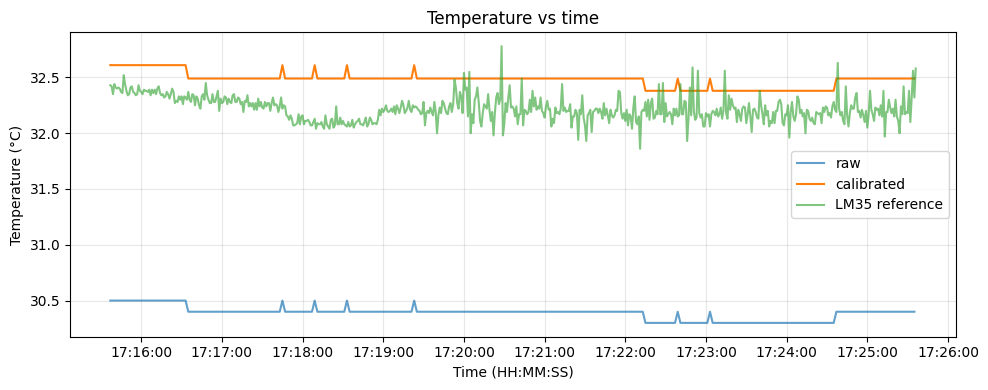

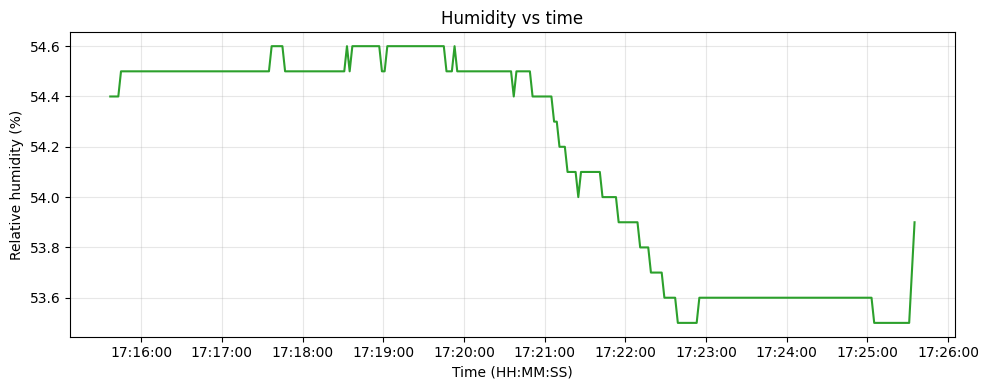

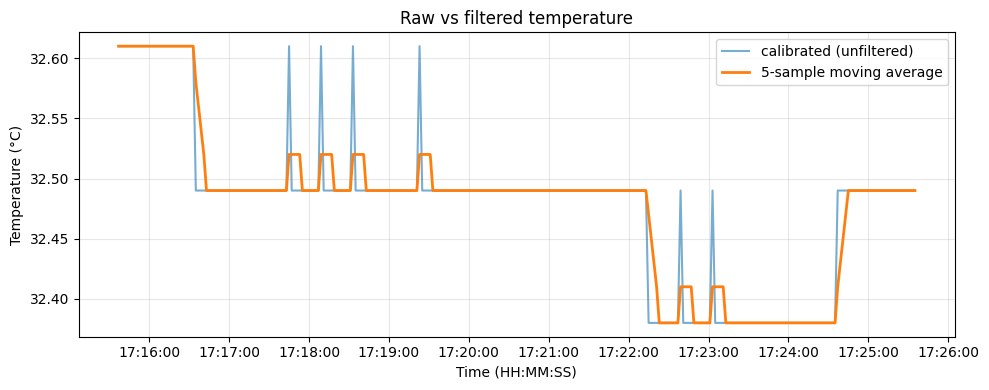

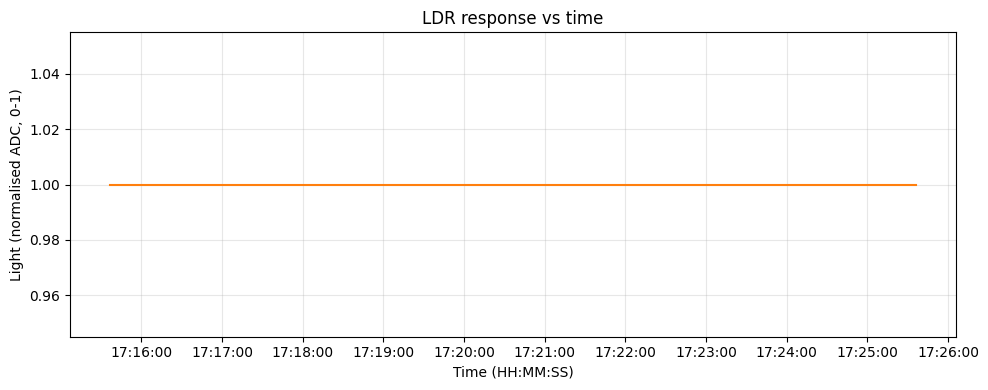

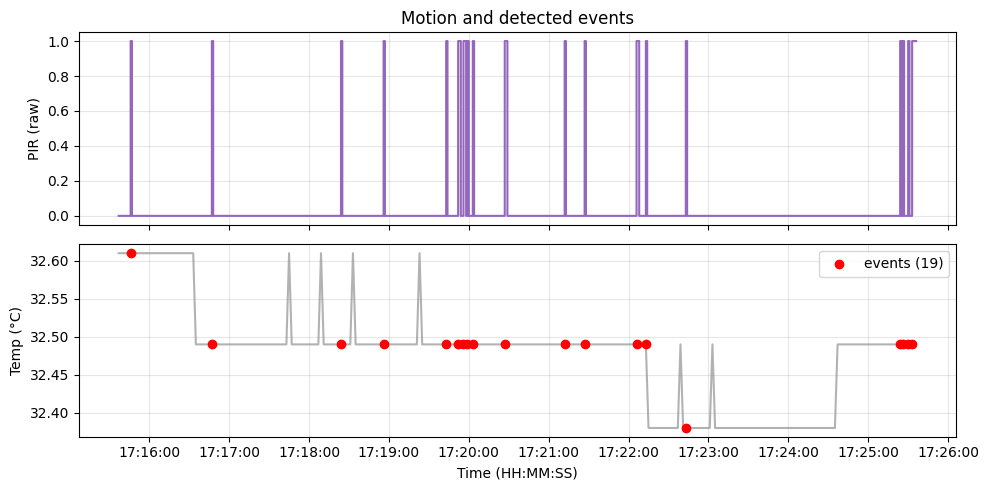

In [6]:
import matplotlib.dates as mdates

# Optional: shade the test phases, times as HH:MM:SS from your notes, e.g.
# PHASES = [("17:18:00", "17:19:00", "LDR covered"), ("17:20:00", "17:21:30", "PIR walk-ins")]
PHASES = []

def finish(ax):
    if USE_CLOCK:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        for a, b, label in PHASES:
            ax.axvspan(pd.to_datetime(a, format="%H:%M:%S"), pd.to_datetime(b, format="%H:%M:%S"),
                       color="gray", alpha=.15, label=label)

def mark_invalid(ax):
    bad = df[(df.dht_fresh == 1) & (df.valid == 0)]["x"]
    for i, t in enumerate(bad):
        ax.axvline(t, color="red", alpha=.25, lw=1, label="invalid read" if i == 0 else None)

# 1. Temperature vs time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fresh.x, fresh.temp, label="raw", alpha=.7)
ax.plot(fresh.x, fresh.temp_cal, label="calibrated")
if df.ref_temp.notna().any():
    ax.plot(df.x, df.ref_temp, label="LM35 reference", alpha=.6)
mark_invalid(ax)
ax.set(xlabel=XLABEL, ylabel="Temperature (°C)", title="Temperature vs time"); ax.legend(); ax.grid(alpha=.3)
finish(ax); fig.tight_layout(); fig.savefig(FIG_DIR / "01_temperature_vs_time.png", dpi=150)

# 2. Humidity vs time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fresh.x, fresh.humidity, color="tab:green"); mark_invalid(ax)
ax.set(xlabel=XLABEL, ylabel="Relative humidity (%)", title="Humidity vs time"); ax.grid(alpha=.3)
finish(ax); fig.tight_layout(); fig.savefig(FIG_DIR / "02_humidity_vs_time.png", dpi=150)

# 3. Raw vs filtered
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fresh.x, fresh.temp_cal, label="calibrated (unfiltered)", alpha=.6)
ax.plot(fresh.x, fresh.temp_filt, label="5-sample moving average", lw=2)
ax.set(xlabel=XLABEL, ylabel="Temperature (°C)", title="Raw vs filtered temperature"); ax.legend(); ax.grid(alpha=.3)
finish(ax); fig.tight_layout(); fig.savefig(FIG_DIR / "03_raw_vs_filtered.png", dpi=150)

# 4. Light (LDR) - characterization
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.x, df.light, color="tab:orange")
ax.set(xlabel=XLABEL, ylabel="Light (normalised ADC, 0-1)", title="LDR response vs time"); ax.grid(alpha=.3)
finish(ax); fig.tight_layout(); fig.savefig(FIG_DIR / "04_light_vs_time.png", dpi=150)

# 5. Motion events and status
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].step(df.x, df.motion, where="post", color="tab:purple"); ax[0].set_ylabel("PIR (raw)")
ev = df[df.event == 1]
ax[1].plot(fresh.x, fresh.temp_cal, color="gray", alpha=.6)
ax[1].scatter(ev.x, ev.temp_cal.fillna(fresh.temp_cal.mean()), color="red", zorder=3, label=f"events ({n_events})")
ax[1].set(xlabel=XLABEL, ylabel="Temp (°C)"); ax[1].legend()
ax[0].set_title("Motion and detected events"); [a.grid(alpha=.3) for a in ax]
[finish(a) for a in ax]; fig.tight_layout(); fig.savefig(FIG_DIR / "05_motion_events.png", dpi=150)
plt.show()

## Export processed dataset

In [7]:
out = df.copy()
out.to_csv(PROC_DIR / "sensor_log_processed.csv", index=False)
summary = {
    "source_file": RAW_FILE.name, "rows": n_obs, "duration_s": float(duration),
    "invalid_dht_reads": invalid_dht_reads, "rows_flagged_invalid": invalid_rows, "events": n_events,
    "effective_rate_hz": rates.round(4).to_dict(),
    "noise_reduction_pct": float(100 * (1 - d_filt / d_raw)),
}
(PROC_DIR / "summary_statistics.json").write_text(json.dumps(summary, indent=2))
stats_tbl.to_csv(PROC_DIR / "descriptive_statistics.csv")
print("Saved processed data, statistics and figures.")

Saved processed data, statistics and figures.
